# Logistic Regression Experiments
This notebook is a lightweight sandbox for primitive test runs.

Run cells in order from top to bottom.

In [77]:
import os
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from preprocessing import build_raw_dataset

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Data root in this repo
BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"
TWEETS_FILE = "tweets.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "reply_count", "favorite_count", "num_urls", "num_mentions"
]

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9


In [78]:
# Block 1: Data loading (full configured datasets)
raw = build_raw_dataset(DATASETS, BASE_DIR, TWEET_FEATURES)

raw.shape

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368


(14368, 48)

In [79]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

tweet_features = [c for c in TWEET_FEATURES if c in raw.columns]
X = pd.concat([X, raw[tweet_features]], axis=1)

X = X.fillna(0)

print(X.columns) 
print(X.shape)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class balance:\n", y.value_counts(dropna=False))

Index(['statuses_count', 'followers_count', 'friends_count',
       'favourites_count', 'listed_count', 'default_profile',
       'default_profile_image', 'verified', 'reply_count', 'favorite_count',
       'num_urls', 'num_mentions'],
      dtype='str')
(14368, 12)
Train shape: (11494, 12)
Test shape: (2874, 12)
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64


In [80]:
# Block 3: Training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

print("Training complete.")
print("Model intercept:", model.intercept_[0])

Training complete.
Model intercept: 7.907489487795258


In [81]:
# Block 4: Evaluation
pred = model.predict(X_test_scaled)
proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, proba):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 features by |coefficient|:")
display(coef_df.head(10))

accuracy:          0.9548
balanced_accuracy: 0.9305
f1_macro:          0.9373
roc_auc:           0.9847
AUPRC:             0.9951

Confusion Matrix:
[[ 614   81]
 [  49 2130]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9261    0.8835    0.9043       695
           1     0.9634    0.9775    0.9704      2179

    accuracy                         0.9548      2874
   macro avg     0.9447    0.9305    0.9373      2874
weighted avg     0.9544    0.9548    0.9544      2874


Top 10 features by |coefficient|:


,feature,coefficient,abs_coefficient
3,favourites_count,-14.828599,14.828599
10,num_urls,11.636506,11.636506
11,num_mentions,10.771476,10.771476
8,reply_count,2.443423,2.443423
0,statuses_count,-1.050603,1.050603
1,followers_count,0.398634,0.398634
9,favorite_count,0.368258,0.368258
7,verified,-0.332593,0.332593
5,default_profile,0.179046,0.179046
6,default_profile_image,-0.105469,0.105469


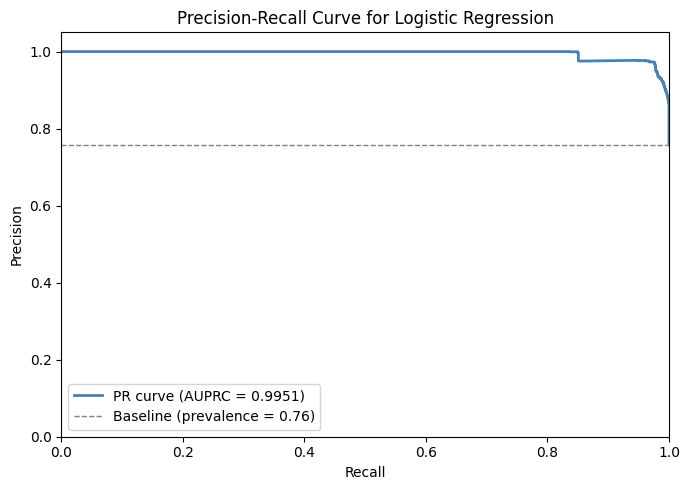

In [82]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test_scaled)[:, 1]

pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (pred_proba >= 0.65).astype(int)

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
auprc = average_precision_score(y_test, y_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR curve (AUPRC = {auprc:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Baseline (prevalence = {y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve for Logistic Regression")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

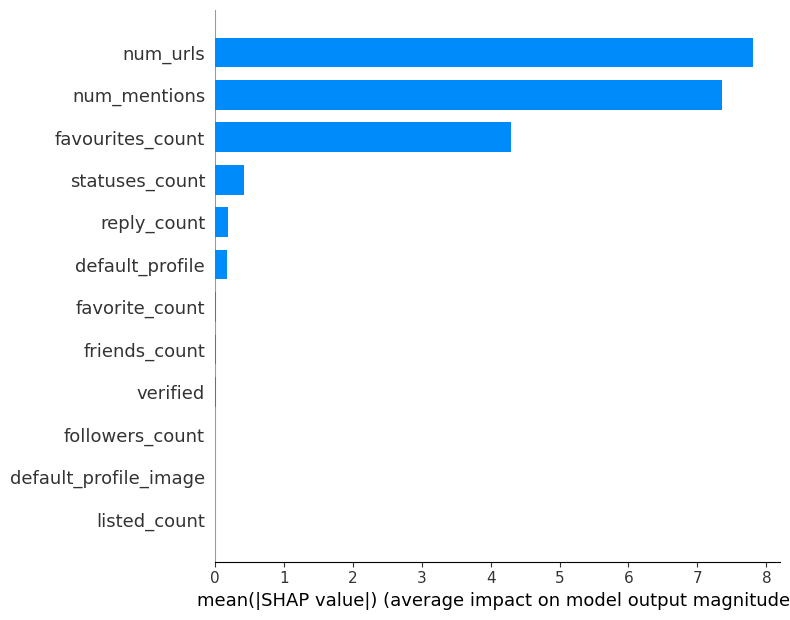

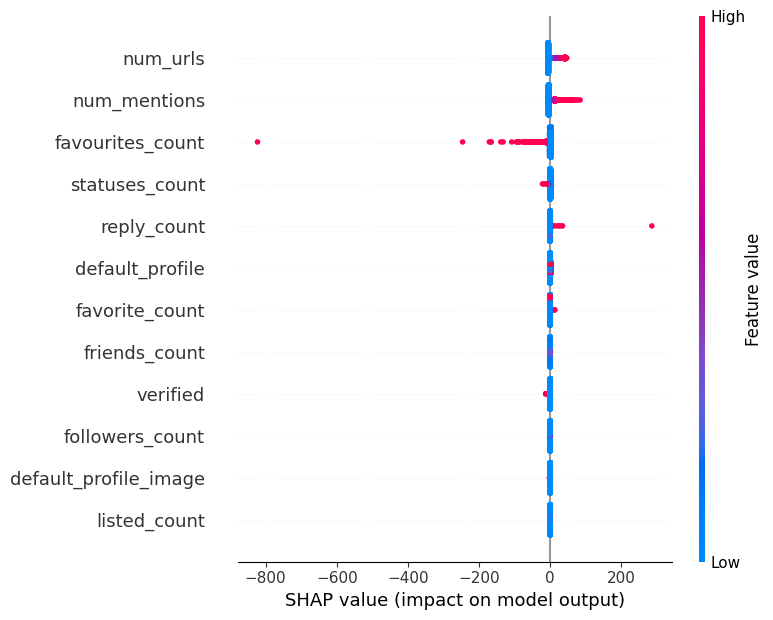

In [83]:
import shap

all_feature_names = ["statuses_count", "followers_count", "friends_count",
                "favourites_count", "listed_count", "default_profile",
                "default_profile_image", "verified", "reply_count", 
                "favorite_count", "num_urls", "num_mentions"]

explainer = shap.LinearExplainer(model, X_test_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=all_feature_names, plot_type="bar")
shap.summary_plot(shap_values, X_test_scaled, feature_names=all_feature_names)


LOBO macro-average (mean ± std):


,mean,std
auprc,0.961218,0.083964
precision_bot,0.986742,0.021588
recall_bot,0.743511,0.283930
accuracy,0.894795,0.120932


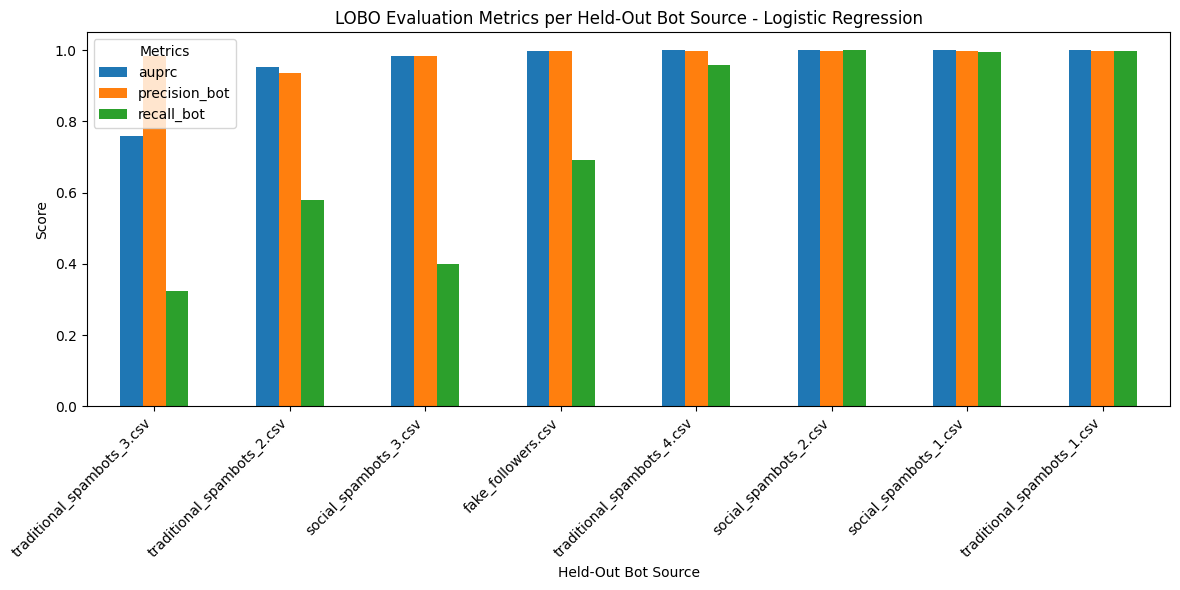

In [84]:
from sklearn.metrics import (
    accuracy_score, average_precision_score,
    precision_score, recall_score
)
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

entity_key = raw["source_file"].astype(str) + "::" + raw.index.astype(str)

genuine_source = "genuine_accounts.csv"
genuine_mask = raw["source_file"] == genuine_source
genuine_idx = raw.index[genuine_mask].to_numpy()

genuine_groups = entity_key.loc[genuine_idx].values

gss_genuine = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

genuine_train_rel, genuine_test_rel = next(
    gss_genuine.split(X.loc[genuine_idx], y.loc[genuine_idx], groups=genuine_groups)
)

genuine_train_idx = genuine_idx[genuine_train_rel]
genuine_test_idx = genuine_idx[genuine_test_rel]

bot_sources = sorted([
    source for source, label in DATASETS.items()
    if label == 1 and (raw["source_file"] == source).any()
])

lobo_rows = []

for held_out_bot_source in bot_sources:

    held_out_bot_idx = raw.index[
        raw["source_file"] == held_out_bot_source
    ].to_numpy()

    train_bot_idx = raw.index[
        (raw["label"] == 1) &
        (raw["source_file"] != held_out_bot_source)
    ].to_numpy()

    train_idx = np.concatenate([genuine_train_idx, train_bot_idx])
    test_idx = np.concatenate([genuine_test_idx, held_out_bot_idx])

    X_lobo_train = X.iloc[train_idx]
    X_lobo_test = X.iloc[test_idx]

    y_lobo_train = y.iloc[train_idx]
    y_lobo_test = y.iloc[test_idx]

    neg = (y_lobo_train == 0).sum()
    pos = (y_lobo_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1

    lobo_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )

    lobo_model.fit(X_lobo_train, y_lobo_train)

    lobo_pred = lobo_model.predict(X_lobo_test)
    lobo_proba = lobo_model.predict_proba(X_lobo_test)[:, 1]

    lobo_rows.append({
        "held_out_bot_source": held_out_bot_source,
        "test_rows": len(test_idx),
        "bot_support": int((y_lobo_test == 1).sum()),
        "genuine_support": int((y_lobo_test == 0).sum()),
        "auprc": average_precision_score(y_lobo_test, lobo_proba),
        "precision_bot": precision_score(y_lobo_test, lobo_pred, pos_label=1, zero_division=0),
        "recall_bot": recall_score(y_lobo_test, lobo_pred, pos_label=1, zero_division=0),
        "accuracy": accuracy_score(y_lobo_test, lobo_pred),
    })

lobo_results = (
    pd.DataFrame(lobo_rows)
    .sort_values("auprc", ascending=True)
    .reset_index(drop=True)
)

summary_cols = ["auprc", "precision_bot", "recall_bot", "accuracy"]

summary_df = pd.DataFrame({
    "mean": lobo_results[summary_cols].mean(),
    "std": lobo_results[summary_cols].std()
})

print("\nLOBO macro-average (mean ± std):")
display(summary_df)

df_plot = lobo_results.set_index("held_out_bot_source")

metrics_to_plot = ["auprc", "precision_bot", "recall_bot"]

df_plot[metrics_to_plot].plot(kind="bar", figsize=(12, 6))

plt.title("LOBO Evaluation Metrics per Held-Out Bot Source - Logistic Regression")
plt.xlabel("Held-Out Bot Source")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

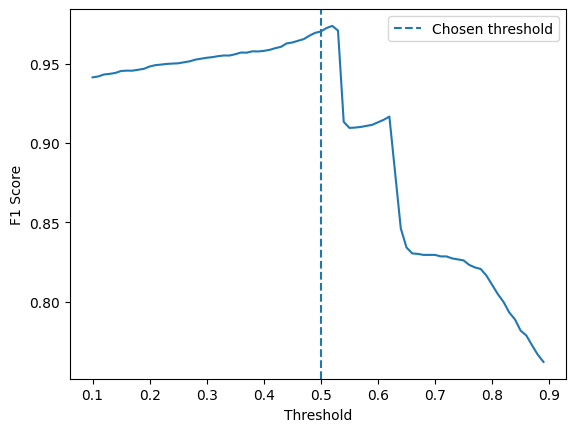

In [85]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (pred_proba >= t).astype(int)) for t in thresholds]
plt.plot(thresholds, f1_scores)
plt.axvline(x=0.5, linestyle='--', label='Chosen threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()

## Run Order
1. Cell 2: imports and constants.
2. Cell 3: full data loading.
3. Cell 4: slicing and preprocessing.
4. Cell 5: training.
5. Cell 6: evaluation.

## Notes
- This notebook now loads all configured dataset files directly.
- If runtime or memory gets heavy, reduce loaded columns or process in chunks.